In [189]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

NumPy for numerical computations ,Pandas was used for data manipulation, Matplotlib for creating graphical representations, and Seaborn for generating advanced statistical visualizations. These libraries provide the foundation for preprocessing, analyzing, and interpreting the dataset effectively.

In [104]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from scipy.stats import zscore
from scipy.stats.mstats import winsorize

SimpleImputer and KNNImputer were used to address missing data through statistical and machine learning-based techniques. The zscore function was utilized to detect outliers, while winsorize was applied to limit the effect of extreme values. These preprocessing steps improve data quality, enhance model performance, and ensure reliable analytical results.

In [105]:
df = pd.read_csv("/content/customer_credit_risk_dataset.csv")

The dataset was loaded into a Pandas DataFrame to enable data analysis, preprocessing, and visualization.

In [106]:
df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST00001,59.0,Male,South,Primary,Salaried,NaN,356606.31,Home,683.0,7,196,0.17,2023-02-20,0
1,CUST00002,49.0,Male,West,Primary,Salaried,748481.68,630858.13,Car,NaN,7,15,0.89,2021-08-10,0
2,CUST00003,35.0,Female,East,Primary,Self-Employed,323897.18,89843.84,Education,778.0,10,362,0.41,2021-10-15,0
3,CUST00004,63.0,Male,North,Primary,Salaried,NaN,393699.55,Car,742.0,0,359,0.82,2022-08-06,0
4,CUST00005,NaN,Male,North,Primary,Salaried,474431.21,413426.78,Business,705.0,1,119,0.46,2018-06-29,1


The first few records were examined to understand the structure of the dataset and identify the available features.

In [107]:
df.tail()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
995,CUST00996,53.0,Male,West,Graduate,Salaried,563928.01,384843.45,Car,806.0,2,11,0.75,2019-12-05,1
996,CUST00997,22.0,Male,West,Graduate,Salaried,517763.98,233882.82,Home,653.0,0,366,0.60,2020-05-18,1
997,CUST00998,34.0,NaN,North,Primary,Self-Employed,689825.65,250429.81,Car,801.0,0,322,0.16,2021-10-16,0
998,CUST00999,60.0,Male,East,Primary,Salaried,297955.29,266903.53,Car,663.0,10,66,0.86,2018-08-21,0
999,CUST01000,60.0,Female,West,Post-Graduate,Salaried,537104.79,333881.99,Home,812.0,5,299,0.13,2020-11-23,0


In [108]:
df.shape

(1000, 15)

The total number of rows and columns was identified to understand the size and dimensionality of the dataset.

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1000 non-null   object 
 1   age                950 non-null    float64
 2   gender             950 non-null    object 
 3   region             1000 non-null   object 
 4   education_level    1000 non-null   object 
 5   employment_type    950 non-null    object 
 6   annual_income      950 non-null    float64
 7   loan_amount        1000 non-null   float64
 8   loan_purpose       1000 non-null   object 
 9   credit_score       950 non-null    float64
 10  repayment_history  1000 non-null   int64  
 11  transaction_count  1000 non-null   int64  
 12  spending_ratio     1000 non-null   float64
 13  join_date          1000 non-null   object 
 14  default_flag       1000 non-null   int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 117.3+ KB


Data types of all variables were reviewed to determine whether each feature was numerical, categorical, or datetime.

In [110]:
df.duplicated().sum()

np.int64(0)

This code is used to check sum of duplicate .

In [111]:
df.isnull().sum()

,0
customer_id,0
age,50
gender,50
region,0
education_level,0
employment_type,50
annual_income,50
loan_amount,0
loan_purpose,0
credit_score,50


This code displays the number of missing (null) values present in each column of the dataset.

In [112]:
df.isnull().sum().sum()

np.int64(250)

This code calculates the total number of missing values across the entire dataset.

In [113]:
(df.isnull().sum() / len(df)) * 100

,0
customer_id,0.0
age,5.0
gender,5.0
region,0.0
education_level,0.0
employment_type,5.0
annual_income,5.0
loan_amount,0.0
loan_purpose,0.0
credit_score,5.0


This shows the percentage of missing values in each column.

In [114]:
null_cols = df.isnull().sum()

null_cols[null_cols > 0]

,0
age,50
gender,50
employment_type,50
annual_income,50
credit_score,50


This displays only those columns that contain missing values.

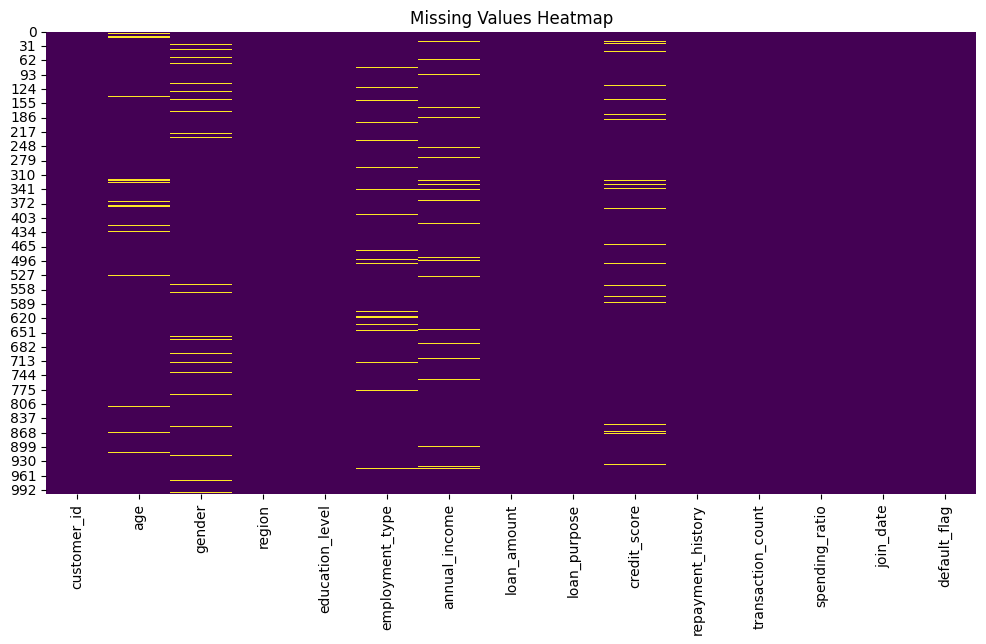

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

The heatmap visually highlights missing values in the dataset. Yellow/light areas indicate missing values, while dark areas indicate available data.

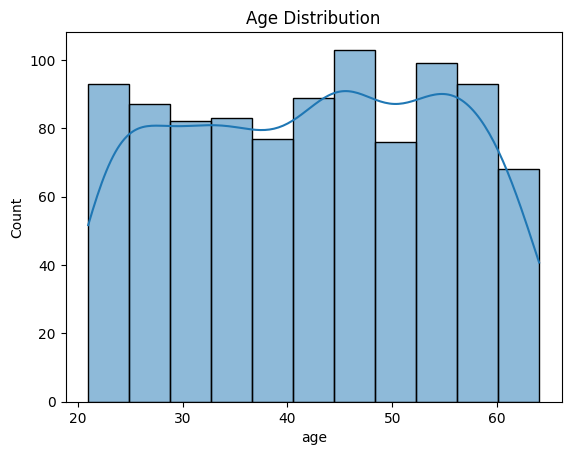

In [116]:
import seaborn as sns

sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")

plt.show()

This code is used to check age dustribution using seaborn.

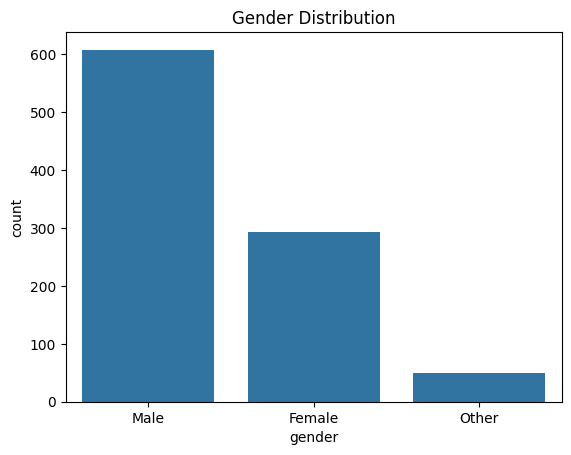

In [117]:
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

this Count plot is used to check gender distribution.

In [118]:
df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag
count,950.000000,9.500000e+02,1.000000e+03,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,42.327368,6.387168e+05,3.220455e+05,674.729474,5.744000,254.859000,0.520110,0.217000
std,12.638826,3.780730e+05,2.206139e+05,89.373439,3.446497,144.639696,0.243835,0.412409
min,21.000000,1.000000e+05,5.000000e+04,419.000000,0.000000,10.000000,0.100000,0.000000
25%,31.000000,4.402520e+05,1.814600e+05,615.000000,3.000000,126.750000,0.310000,0.000000
50%,43.000000,6.000084e+05,2.921597e+05,676.000000,6.000000,259.000000,0.520000,0.000000
75%,53.000000,7.894757e+05,4.216670e+05,739.750000,9.000000,378.000000,0.730000,0.000000
max,64.000000,3.887411e+06,2.321311e+06,850.000000,11.000000,499.000000,0.950000,1.000000


Summary statistics were generated to understand the central tendency, spread, and distribution of numerical variables.

In [119]:
from sklearn.impute import SimpleImputer

mean_imp = SimpleImputer(strategy='mean')

df[['age']] = mean_imp.fit_transform(df[['age']])

Mean Imputation was applied to the Age column. Missing values were replaced with the average age of customers. This method helps maintain the overall distribution of the data and prevents loss of records.

Mean imputation is simple and effective for numerical data that is approximately normally distributed.

In [120]:
median_imp = SimpleImputer(strategy='median')

df[['annual_income']] = median_imp.fit_transform(
    df[['annual_income']]
)

Median Imputation was used to fill missing values in the annual_income column. The median value was chosen because financial data often contains outliers, and the median is less affected by extreme values than the mean.

Median imputation is preferred when the data is skewed or contains outliers.

In [121]:
mode_imp = SimpleImputer(strategy='most_frequent')

df[['gender']] = mode_imp.fit_transform(
    df[['gender']]
)

Mode Imputation was applied to the employment_type column because it is a categorical variable. Missing values were replaced with the most frequently occurring employment category, preserving the original distribution of the data.

Mode imputation is suitable for categorical variables where mean and median cannot be calculated.

In [122]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)

df[['credit_score']] = knn.fit_transform(
    df[['credit_score']]
)

KNN Imputation was used to estimate missing values in the credit_score column by considering the values of similar customers.

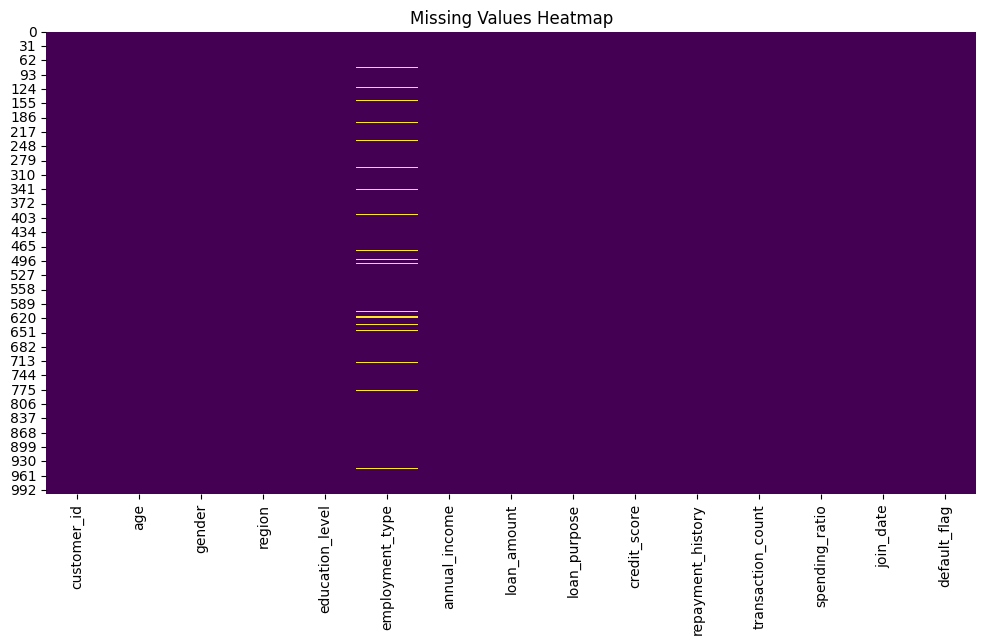

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

In [124]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy='most_frequent'
)

df[['employment_type']] = imputer.fit_transform(
    df[['employment_type']]
)

Most Frequent Imputation was applied to the employment_type column because it is a categorical variable. Missing values were replaced with the most commonly used values.

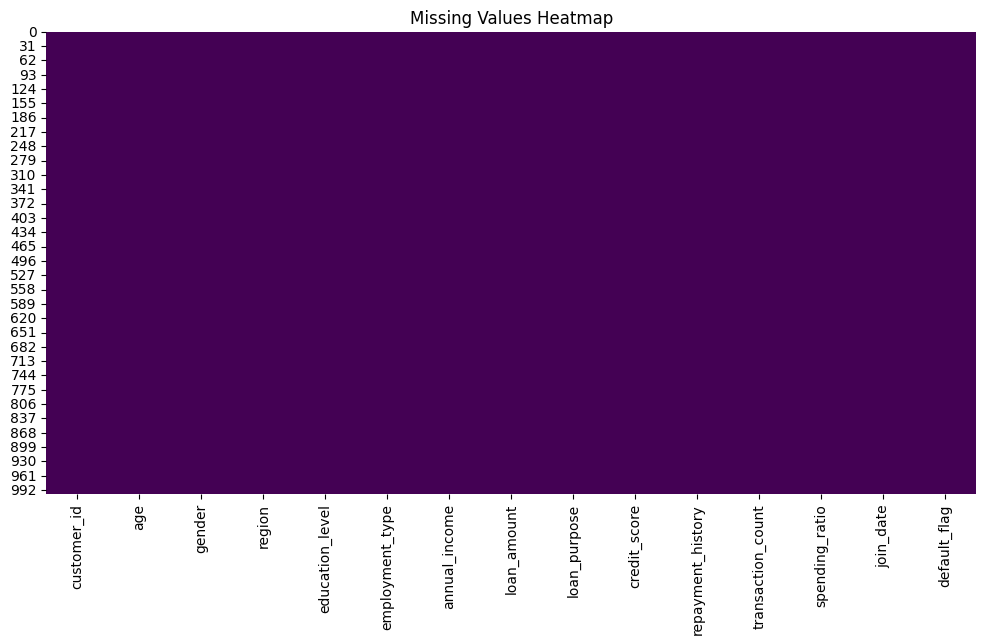

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

This code use to describe the data set is clean and fill all null values completely.

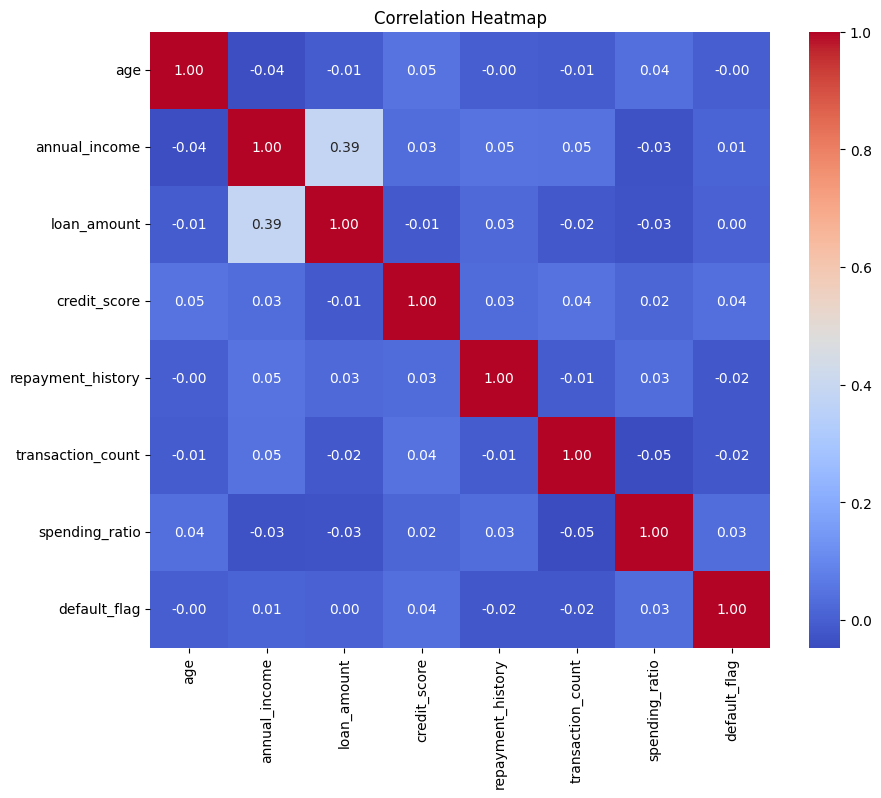

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows relationships among numerical variables. Strong positive correlations indicate variables that increase together, while negative correlations indicate inverse relationships.

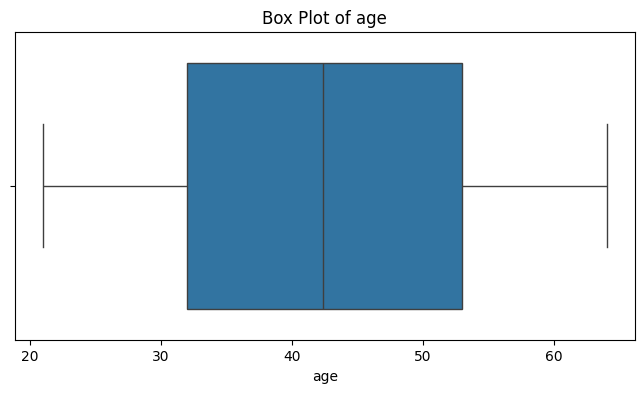

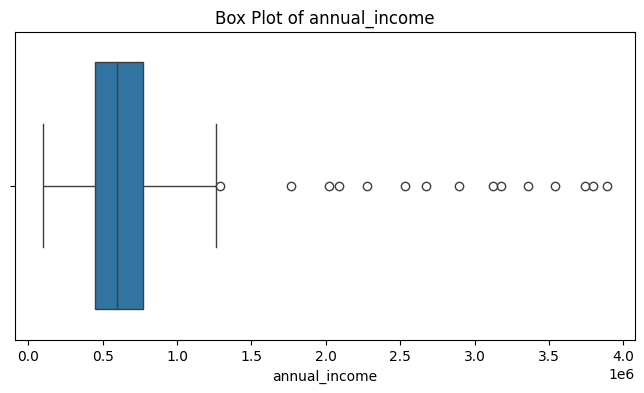

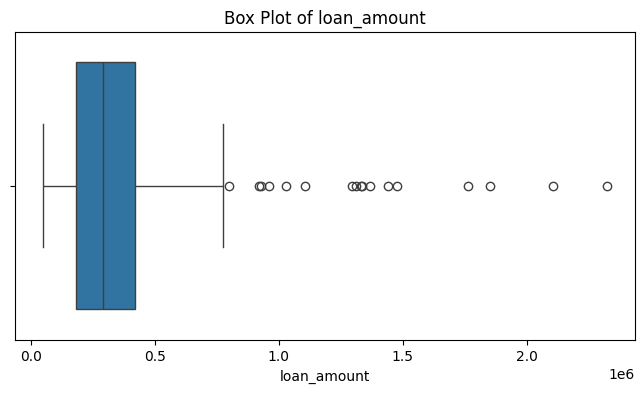

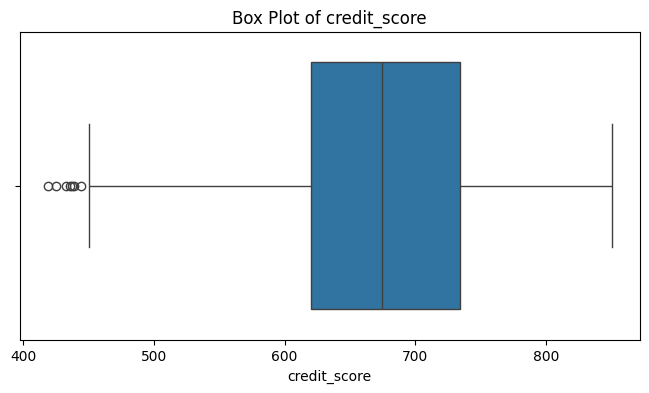

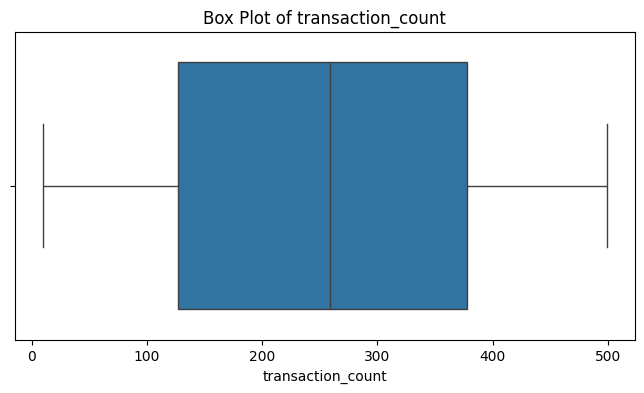

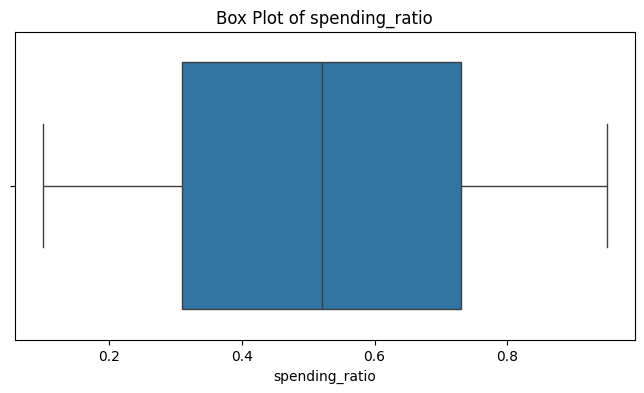

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'age',
    'annual_income',
    'loan_amount',
    'credit_score',
    'transaction_count',
    'spending_ratio'
]

for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f'Box Plot of {col}')

    plt.show()

Box plots were generated for all numerical variables to identify outliers and understand the spread of data.

In [128]:
from sklearn.impute import SimpleImputer

median_imp = SimpleImputer(strategy='median')

df[['annual_income','credit_score']] = median_imp.fit_transform(
    df[['annual_income','credit_score']]
)

The columns annual_income, loan_amount, and credit_score contained missing values. Median imputation was used to replace these missing values because financial data often contains outliers.

In [129]:
df['loan_amount'] = df['loan_amount'].fillna(
    df['loan_amount'].median()
)

In [130]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(
    zscore(df[['annual_income','loan_amount','credit_score']])
)

outliers = (z_scores > 3)

print(outliers.sum())

27


The Z-Score method was used to identify outliers in the numerical features. It measures how far a value is from the mean in terms of standard deviations.

In [131]:
for col in ['annual_income','loan_amount','credit_score']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, len(outliers))

annual_income 15
loan_amount 17
credit_score 7


The Interquartile Range (IQR) method was used to detect outliers by analyzing the spread of the middle 50% of the data.

In [132]:
for col in ['annual_income','loan_amount','credit_score']:

    lower = df[col].quantile(0.01)

    upper = df[col].quantile(0.99)

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

The Percentile method was applied to identify extreme values at both ends of the distribution. Values below the 1st percentile and above the 99th percentile were treated as outliers.

In [133]:
from scipy.stats.mstats import winsorize

df['annual_income'] = winsorize(
    df['annual_income'],
    limits=[0.01,0.01]
)

df['loan_amount'] = winsorize(
    df['loan_amount'],
    limits=[0.01,0.01]
)

df['credit_score'] = winsorize(
    df['credit_score'],
    limits=[0.01,0.01]
)

This Winsorization was used to reduce the impact of extreme values without removing any records from the dataset. Instead of deleting outliers, the extreme values were replaced with the nearest acceptable values.

In [134]:
df['debt_income_ratio'] = (
    df['loan_amount'] /
    df['annual_income']
)

df[['loan_amount','annual_income','debt_income_ratio']].head()

,loan_amount,annual_income,debt_income_ratio
0,356606.31,600008.44,0.594335
1,630858.13,748481.68,0.842850
2,89843.84,323897.18,0.277384
3,393699.55,600008.44,0.656157
4,413426.78,474431.21,0.871416


A customer with a high loan amount and low income has a higher financial burden.

A new feature called debt_income_ratio was created by dividing loan amount by annual income. This feature helps measure the customer's financial burden and may be useful in predicting loan default risk.

In [135]:
df['join_date'] = pd.to_datetime(
    df['join_date']
)

The join_date column was converted into datetime format to enable extraction of meaningful date-related features.

In [136]:
df['join_year'] = df['join_date'].dt.year

The year component was extracted from the join date to analyze customer trends across different years.

In [137]:
df['join_month'] = df['join_date'].dt.month

The month component was extracted to identify seasonal patterns in customer activity.

In [138]:
df['join_day'] = df['join_date'].dt.day

The day feature was extracted from the join date to provide additional temporal information.

In [139]:
df['join_weekday'] = df['join_date'].dt.dayofweek

The weekday feature indicates the day of the week when the customer joined, which may reveal behavioral patterns.

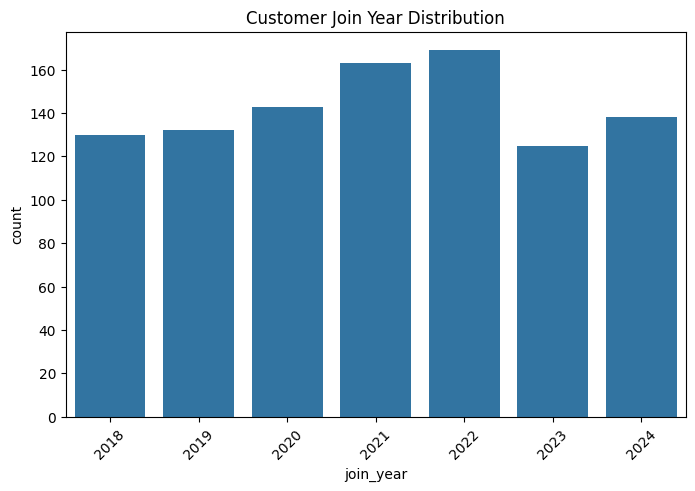

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='join_year',
    data=df
)

plt.title("Customer Join Year Distribution")
plt.xticks(rotation=45)

plt.show()

The chart shows the number of customers joining in each year and helps identify growth trends over time.

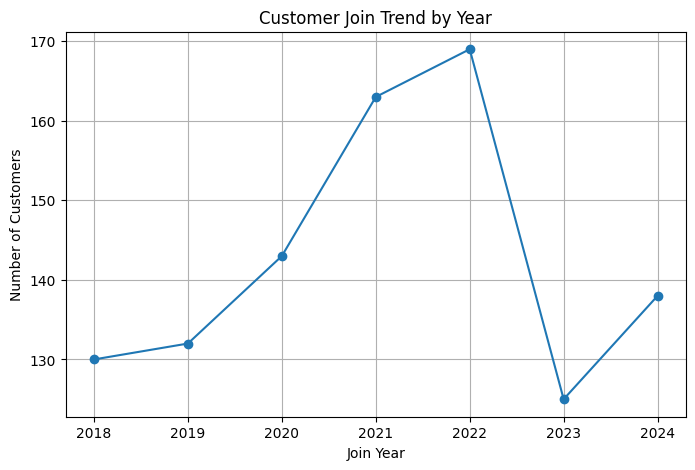

In [141]:
import matplotlib.pyplot as plt

yearly_customers = df['join_year'].value_counts().sort_index()
plt.figure(figsize=(8,5))

plt.plot(
    yearly_customers.index,
    yearly_customers.values,
    marker='o'
)

plt.title("Customer Join Trend by Year")
plt.xlabel("Join Year")
plt.ylabel("Number of Customers")

plt.grid(True)

plt.show()

A trend line graph was created to analyze the number of customers joining the organization over different years. The graph helps visualize growth or decline in customer acquisition over time.

In [142]:
df['education_level'].unique()

array(['Primary', 'Post-Graduate', 'Graduate', 'Secondary'], dtype=object)

This code displays all unique education categories present in the dataset. It helps verify the order before applying ordinal encoding

In [143]:
from sklearn.preprocessing import OrdinalEncoder

education_order = [
    [
        'Primary',
        'Secondary',
        'Graduate',
        'Post-Graduate'
    ]
]

encoder = OrdinalEncoder(
    categories=education_order
)

df[['education_level']] = encoder.fit_transform(
    df[['education_level']]
)

df.head()

,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag,debt_income_ratio,join_year,join_month,join_day,join_weekday
0,CUST00001,59.000000,Male,South,0.0,Salaried,600008.44,356606.31,Home,683.000000,7,196,0.17,2023-02-20,0,0.594335,2023,2,20,0
1,CUST00002,49.000000,Male,West,0.0,Salaried,748481.68,630858.13,Car,674.729474,7,15,0.89,2021-08-10,0,0.842850,2021,8,10,1
2,CUST00003,35.000000,Female,East,0.0,Self-Employed,323897.18,89843.84,Education,778.000000,10,362,0.41,2021-10-15,0,0.277384,2021,10,15,4
3,CUST00004,63.000000,Male,North,0.0,Salaried,600008.44,393699.55,Car,742.000000,0,359,0.82,2022-08-06,0,0.656157,2022,8,6,5
4,CUST00005,42.327368,Male,North,0.0,Salaried,474431.21,413426.78,Business,705.000000,1,119,0.46,2018-06-29,1,0.871416,2018,6,29,4


he education_level variable contains ordered categories ranging from Primary to Post-Graduate. Since these categories have a natural hierarchy, Ordinal Encoding was applied. The categories were converted into numerical values.

Verify Encoding

In [144]:
df[['education_level']].head(10)

,education_level
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,3.0
7,2.0
8,0.0
9,1.0


0.0 = Primary
1.0 = Secondary
2.0 = Graduate
3.0 = Post-Graduate

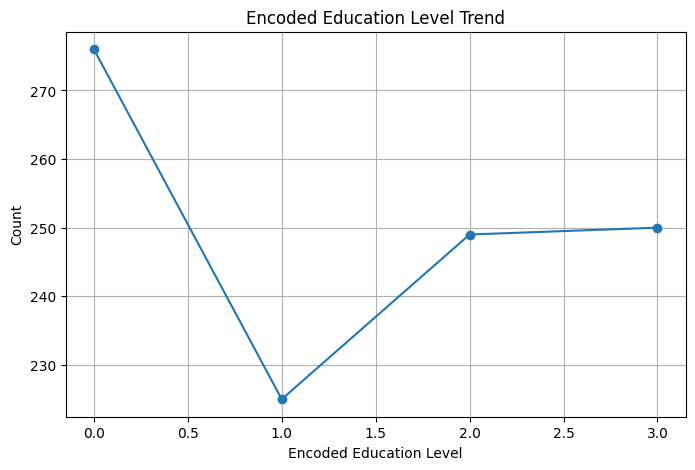

In [145]:
import matplotlib.pyplot as plt

edu_counts = (
    df['education_level']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    edu_counts.index,
    edu_counts.values,
    marker='o'
)

plt.title("Encoded Education Level Trend")
plt.xlabel("Encoded Education Level")
plt.ylabel("Count")

plt.grid(True)

plt.show()

The encoded education levels were visualized to verify that the ordinal ranking was maintained after transformation.

In [146]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

This code displays all unique categories present in the gender column. It helps understand the values before encoding.

Machine learning algorithms work with numerical data.
Label Encoding converts text categories into numbers.
It is simple and efficient for binary or small categorical variables.

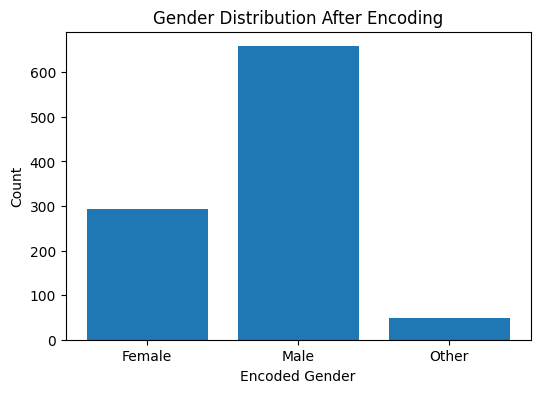

In [147]:
import matplotlib.pyplot as plt

gender_counts = (
    df['gender']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,4))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution After Encoding")
plt.xlabel("Encoded Gender")
plt.ylabel("Count")

plt.show()

The gender column contained categorical values that could not be directly used in machine learning algorithms. Label Encoding was applied to convert each category into a unique numerical value.

In [148]:
print(df['region'].unique())

print(df['loan_purpose'].unique())

['South' 'West' 'East' 'North']
['Home' 'Car' 'Education' 'Business' 'Personal']


This code displays all unique categories present in the region and loan_purpose columns before encoding.

In [149]:
df = pd.get_dummies(
    df,
    columns=[
        'region',
        'loan_purpose'
    ],
    dtype=int
)

df.head()

,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,join_weekday,region_East,region_North,region_South,region_West,loan_purpose_Business,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal
0,CUST00001,59.000000,Male,0.0,Salaried,600008.44,356606.31,683.000000,7,196,...,0,0,0,1,0,0,0,0,1,0
1,CUST00002,49.000000,Male,0.0,Salaried,748481.68,630858.13,674.729474,7,15,...,1,0,0,0,1,0,1,0,0,0
2,CUST00003,35.000000,Female,0.0,Self-Employed,323897.18,89843.84,778.000000,10,362,...,4,1,0,0,0,0,0,1,0,0
3,CUST00004,63.000000,Male,0.0,Salaried,600008.44,393699.55,742.000000,0,359,...,5,0,1,0,0,0,1,0,0,0
4,CUST00005,42.327368,Male,0.0,Salaried,474431.21,413426.78,705.000000,1,119,...,4,0,1,0,0,1,0,0,0,0


Machine learning algorithms cannot directly process text categories.
One-Hot Encoding creates separate binary columns for each category.
It avoids assigning any false order or ranking to categories.

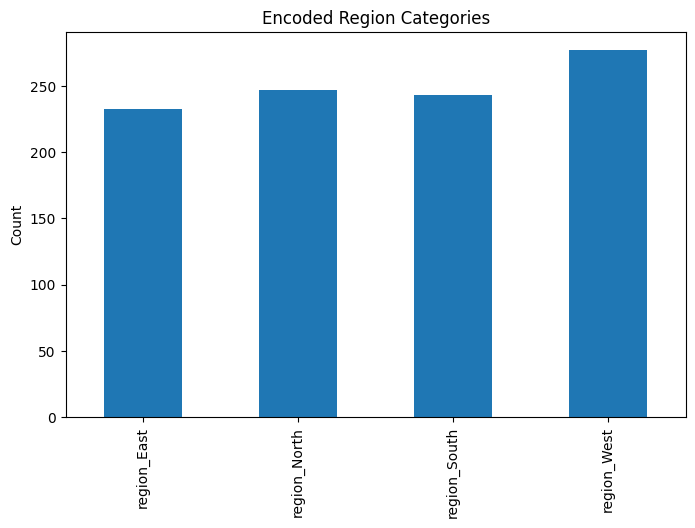

In [150]:
region_cols = [col for col in df.columns if 'region_' in col]

df[region_cols].sum().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Encoded Region Categories")

plt.ylabel("Count")

plt.show()

The region and loan_purpose variables are nominal categorical features that do not have any natural order. Therefore, One-Hot Encoding was applied to convert each category into separate binary columns. This transformation allows machine learning algorithms to process categorical information without introducing any artificial ranking among categories.

In [151]:
df['income_group'] = pd.cut(
    df['annual_income'],
    bins=3,
    labels=[
        'Low Income',
        'Medium Income',
        'High Income'
    ]
)

df[['annual_income','income_group']].head()

,annual_income,income_group
0,600008.44,Low Income
1,748481.68,Low Income
2,323897.18,Low Income
3,600008.44,Low Income
4,474431.21,Low Income


pd.cut() divides the data into equal-width intervals.
Converts continuous income values into categories.

In [152]:
df['income_group'].value_counts()

,count
income_group,
Low Income,799
Medium Income,187
High Income,14


This code shows how many customers belong to each income category.

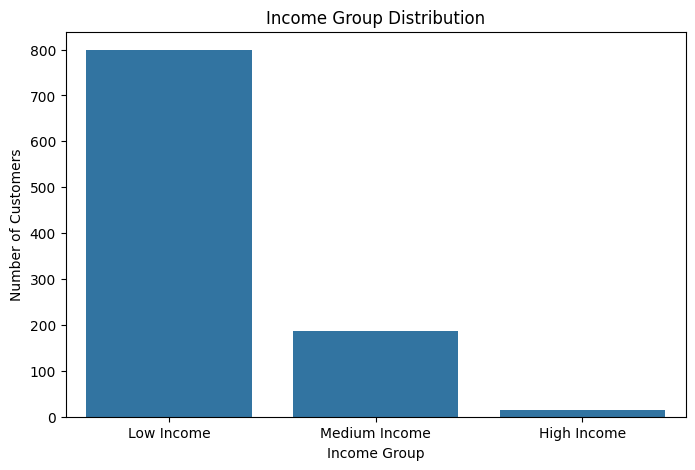

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='income_group',
    data=df,
    order=[
        'Low Income',
        'Medium Income',
        'High Income'
    ]
)

plt.title("Income Group Distribution")
plt.xlabel("Income Group")
plt.ylabel("Number of Customers")

plt.show()

The chart shows the distribution of customers across Low, Medium, and High income groups. It helps identify which income category contains the largest number of customers.

In [154]:
df['transaction_bin'] = pd.qcut(
    df['transaction_count'],
    q=4,
    labels=[
        'Q1',
        'Q2',
        'Q3',
        'Q4'
    ]
)

df[['transaction_count','transaction_bin']].head()

,transaction_count,transaction_bin
0,196,Q2
1,15,Q1
2,362,Q3
3,359,Q3
4,119,Q1


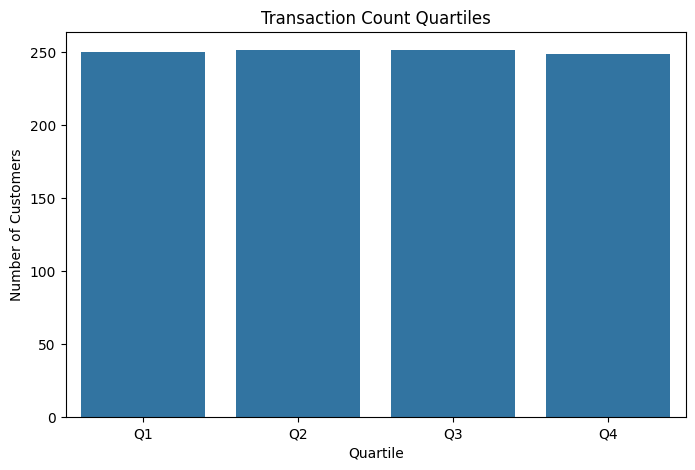

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='transaction_bin',
    data=df,
    order=['Q1','Q2','Q3','Q4']
)

plt.title("Transaction Count Quartiles")
plt.xlabel("Quartile")
plt.ylabel("Number of Customers")

plt.show()

The chart displays customers grouped into four transaction-based quartiles. Since quantile binning creates equal-sized groups, the bars should be relatively similar in height.

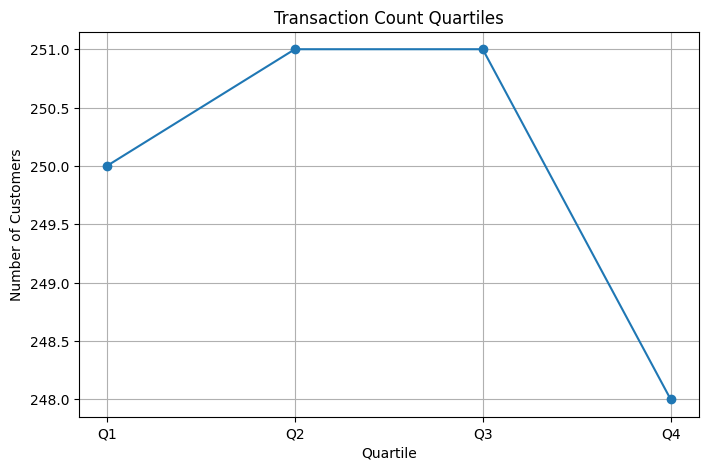

In [156]:
quartile_counts = (
    df['transaction_bin']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    quartile_counts.index,
    quartile_counts.values,
    marker='o'
)

plt.title("Transaction Count Quartiles")
plt.xlabel("Quartile")
plt.ylabel("Number of Customers")

plt.grid(True)

plt.show()

The trend line visualizes the distribution of customers across transaction quartiles and helps compare group sizes.

In [157]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['kmeans_bin'] = kmeans.fit_predict(
    df[['transaction_count']]
)

df[['transaction_count','kmeans_bin']].head()

,transaction_count,kmeans_bin
0,196,2
1,15,0
2,362,1
3,359,1
4,119,0


n_clusters=4 creates four groups.
Customers with similar transaction counts are placed in the same cluster.
Helps identify customer behavior segments.

In [158]:
df['kmeans_bin'].value_counts()

,count
kmeans_bin,
1,266
0,261
3,242
2,231


This code shows the number of customers assigned to each cluster.

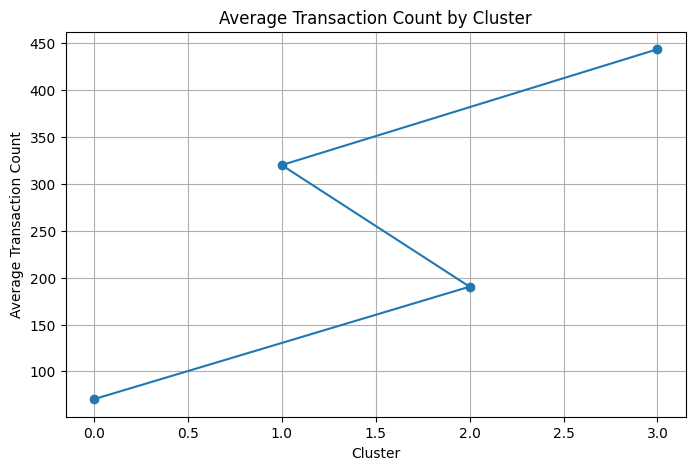

In [159]:
cluster_means = (
    df.groupby('kmeans_bin')['transaction_count']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))

plt.plot(
    cluster_means.index,
    cluster_means.values,
    marker='o'
)

plt.title("Average Transaction Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Transaction Count")

plt.grid(True)

plt.show()

This trend line shows the average transaction count for each cluster. Higher clusters indicate customers with more transaction activity.

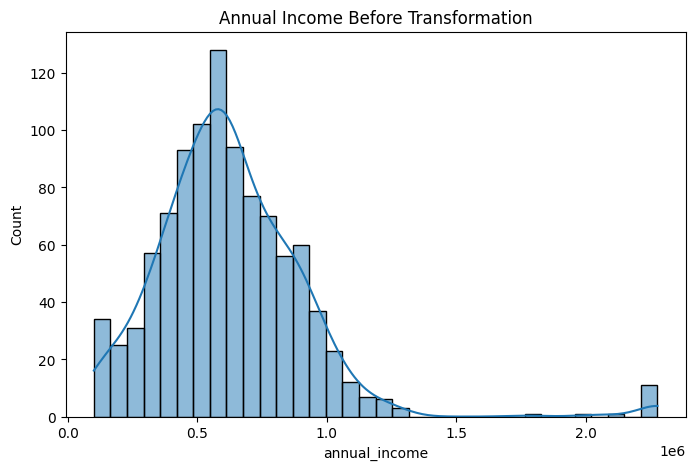

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['annual_income'],
    kde=True
)

plt.title("Annual Income Before Transformation")

plt.show()

The histogram was plotted to examine the distribution of annual income. A skewed distribution indicates the presence of extreme values and may affect model performance.

In [161]:
import numpy as np

df['annual_income_log'] = np.log1p(
    df['annual_income']
)

df[['annual_income','annual_income_log']].head()

,annual_income,annual_income_log
0,600008.44,13.304701
1,748481.68,13.525803
2,323897.18,12.688184
3,600008.44,13.304701
4,474431.21,13.069874


Log Transformation was applied to reduce skewness and compress large values within the annual income variable.

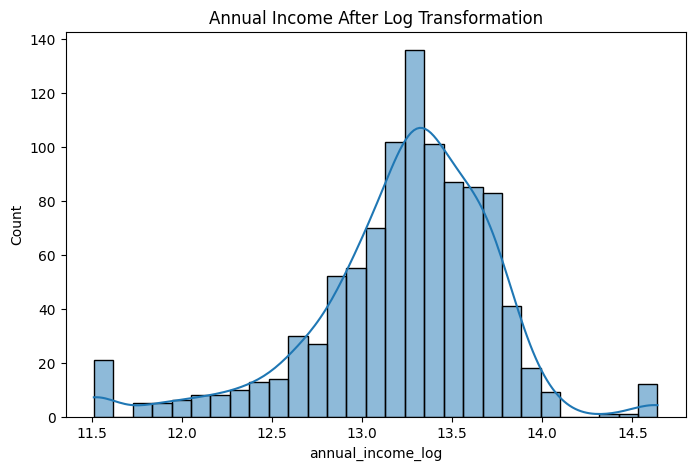

In [162]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['annual_income_log'],
    kde=True
)

plt.title("Annual Income After Log Transformation")

plt.show()

In [163]:
df['annual_income_sqrt'] = np.sqrt(
    df['annual_income']
)

df[['annual_income','annual_income_sqrt']].head()

,annual_income,annual_income_sqrt
0,600008.44,774.602117
1,748481.68,865.148357
2,323897.18,569.119654
3,600008.44,774.602117
4,474431.21,688.789670


Square Root Transformation was used to reduce moderate skewness and improve data distribution.

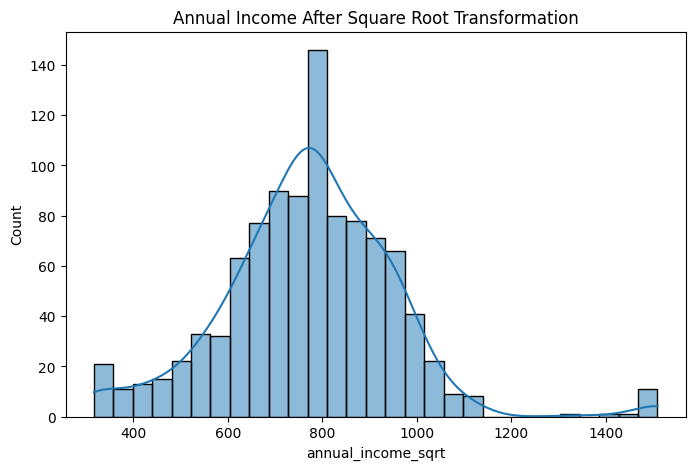

In [164]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['annual_income_sqrt'],
    kde=True
)

plt.title("Annual Income After Square Root Transformation")

plt.show()

In [165]:
df['annual_income_reciprocal'] = (
    1 / (df['annual_income'] + 1)
)

df[['annual_income','annual_income_reciprocal']].head()

,annual_income,annual_income_reciprocal
0,600008.44,0.000002
1,748481.68,0.000001
2,323897.18,0.000003
3,600008.44,0.000002
4,474431.21,0.000002


Reciprocal Transformation was applied to minimize the influence of extreme values and stabilize the distribution

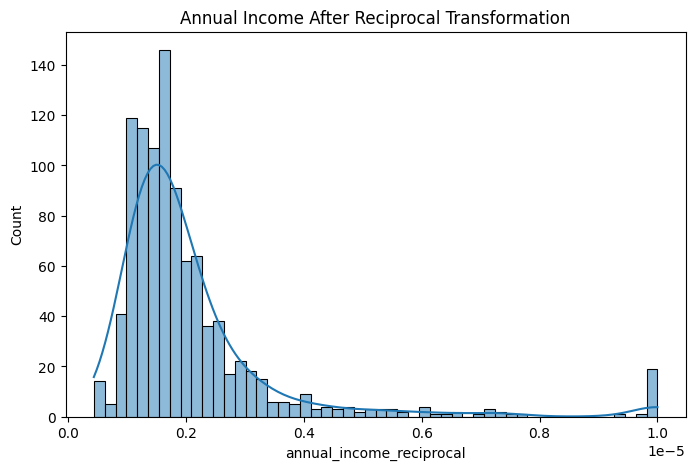

In [166]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['annual_income_reciprocal'],
    kde=True
)

plt.title("Annual Income After Reciprocal Transformation")

plt.show()

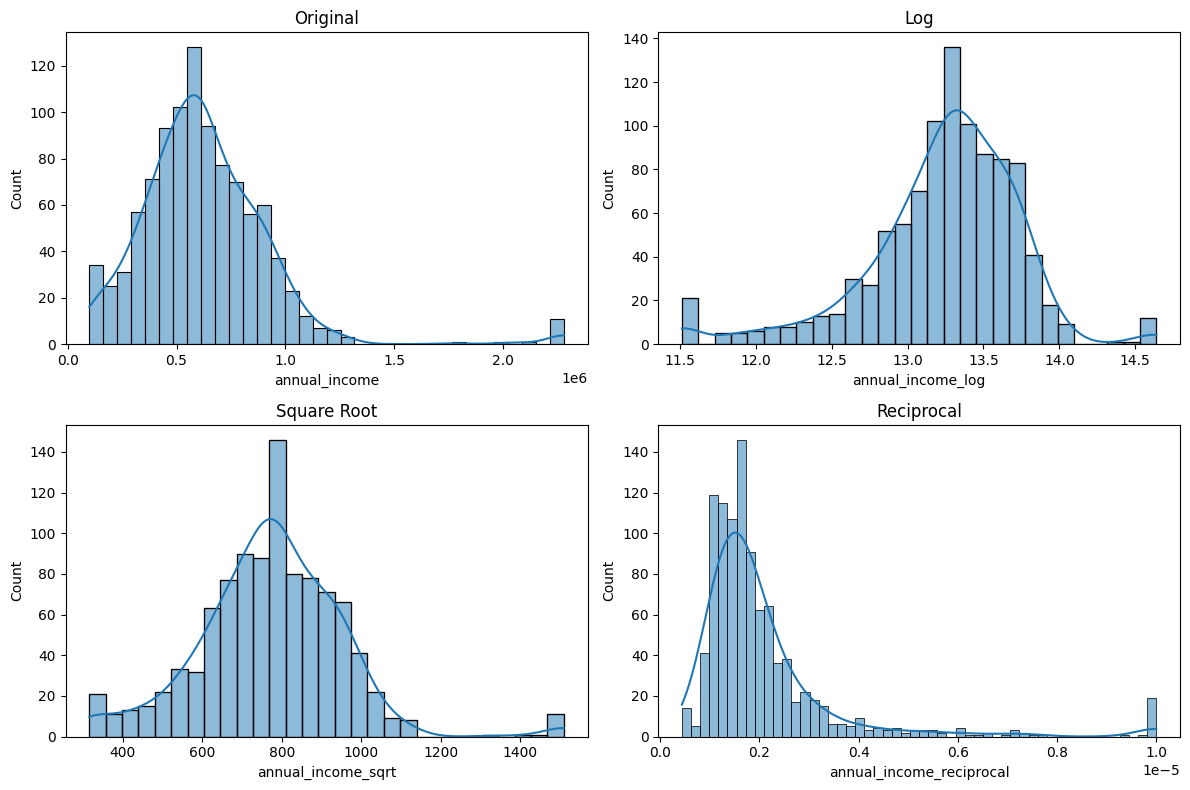

In [167]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.histplot(df['annual_income'], kde=True)
plt.title("Original")

plt.subplot(2,2,2)
sns.histplot(df['annual_income_log'], kde=True)
plt.title("Log")

plt.subplot(2,2,3)
sns.histplot(df['annual_income_sqrt'], kde=True)
plt.title("Square Root")

plt.subplot(2,2,4)
sns.histplot(df['annual_income_reciprocal'], kde=True)
plt.title("Reciprocal")

plt.tight_layout()
plt.show()

In [168]:
from scipy.stats import boxcox

df['annual_income_boxcox'], lambda_value = boxcox(
    df['annual_income']
)

print("Lambda Value:", lambda_value)

Lambda Value: 0.3980007967678658


Box-Cox Transformation was performed to make the annual income distribution closer to normal and improve model performance.

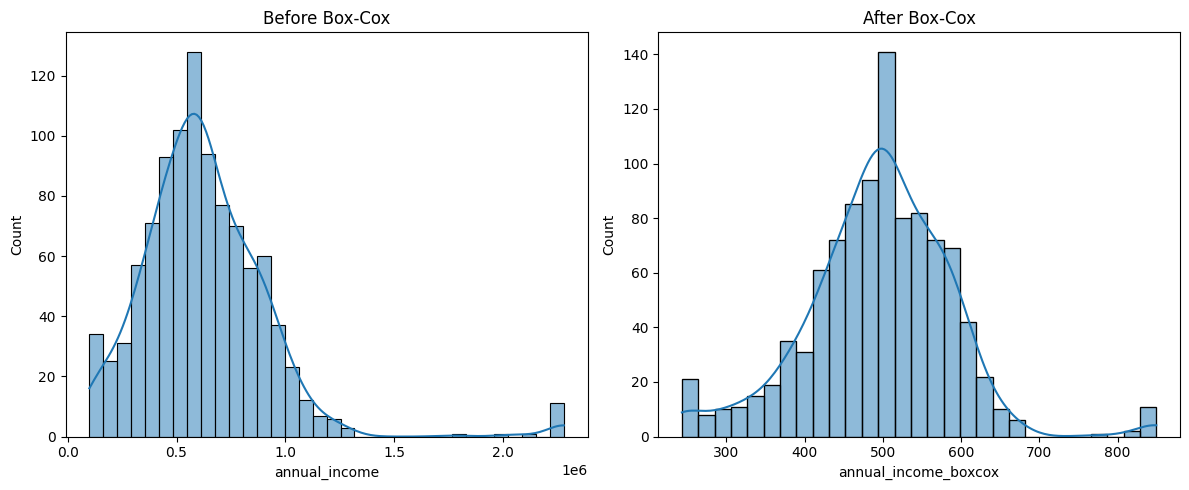

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    df['annual_income'],
    kde=True
)

plt.title("Before Box-Cox")

plt.subplot(1,2,2)

sns.histplot(
    df['annual_income_boxcox'],
    kde=True
)

plt.title("After Box-Cox")

plt.tight_layout()

plt.show()

In [170]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(
    method='yeo-johnson'
)

df['loan_amount_yeojohnson'] = pt.fit_transform(
    df[['loan_amount']]
)

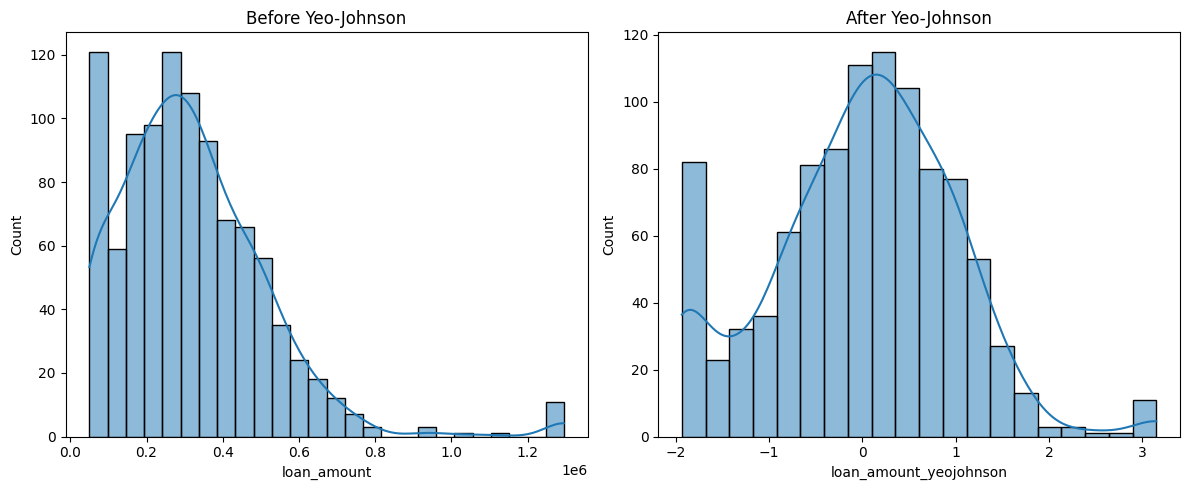

In [171]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    df['loan_amount'],
    kde=True
)

plt.title("Before Yeo-Johnson")

plt.subplot(1,2,2)

sns.histplot(
    df['loan_amount_yeojohnson'],
    kde=True
)

plt.title("After Yeo-Johnson")

plt.tight_layout()

plt.show()

In [172]:
numerical_cols = [
    'annual_income',
    'loan_amount',
    'credit_score'
]

In [173]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(
    df[numerical_cols]
)

df.head()

,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,loan_purpose_Home,loan_purpose_Personal,income_group,transaction_bin,kmeans_bin,annual_income_log,annual_income_sqrt,annual_income_reciprocal,annual_income_boxcox,loan_amount_yeojohnson
0,CUST00001,59.000000,Male,0.0,Salaried,-0.088903,0.190001,0.093526,7,196,...,1,0,Low Income,Q2,2,13.304701,774.602117,0.000002,498.475405,0.379060
1,CUST00002,49.000000,Male,0.0,Salaried,0.403199,1.564650,-0.001963,7,15,...,0,0,Low Income,Q1,0,13.525803,865.148357,0.000001,544.559894,1.440231
2,CUST00003,35.000000,Female,0.0,Self-Employed,-1.004050,-1.147109,1.190364,10,362,...,0,0,Low Income,Q3,1,12.688184,569.119654,0.000003,389.466172,-1.413371
3,CUST00004,63.000000,Male,0.0,Salaried,-0.088903,0.375925,0.774720,0,359,...,0,0,Low Income,Q3,1,13.304701,774.602117,0.000002,498.475405,0.547169
4,CUST00005,42.327368,Male,0.0,Salaried,-0.505118,0.474805,0.347531,1,119,...,0,0,Low Income,Q1,0,13.069874,688.789670,0.000002,453.773853,0.632573


StandardScaler standardized numerical variables to have a mean of zero and a standard deviation of one.

In [174]:
print(df[numerical_cols].mean())

print(df[numerical_cols].std())

annual_income    2.344791e-16
loan_amount     -2.398082e-16
credit_score    -5.506706e-17
dtype: float64
annual_income    1.0005
loan_amount      1.0005
credit_score     1.0005
dtype: float64


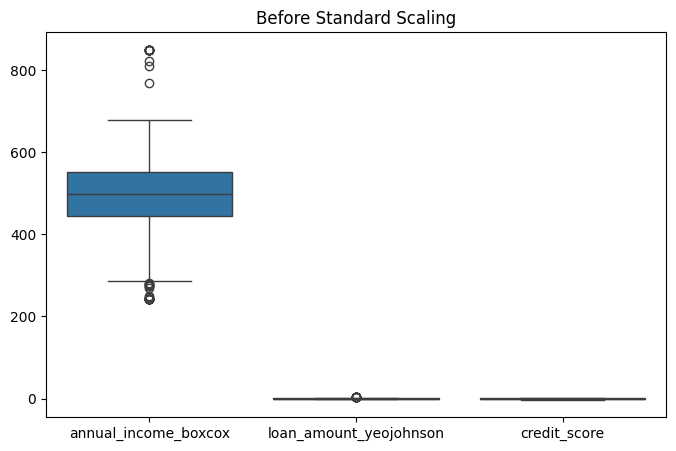

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[['annual_income_boxcox',
             'loan_amount_yeojohnson',
             'credit_score']]
)

plt.title("Before Standard Scaling")

plt.show()

The box plot shows that the variables have different ranges and distributions before scaling.

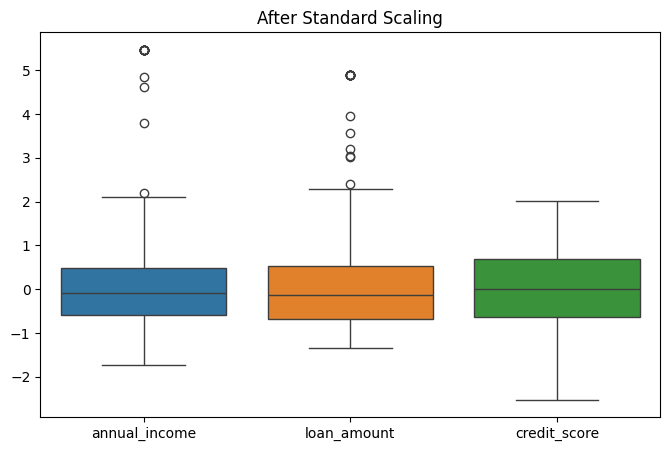

In [176]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[numerical_cols]
)

plt.title("After Standard Scaling")

plt.show()

After applying StandardScaler, the features are brought to a common scale. This makes comparisons easier and improves machine learning model efficiency.

In [177]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

numerical_cols = [
    'annual_income',
    'loan_amount',
    'credit_score'
]

df[numerical_cols] = minmax.fit_transform(
    df[numerical_cols]
)

df.head()

,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,loan_purpose_Home,loan_purpose_Personal,income_group,transaction_bin,kmeans_bin,annual_income_log,annual_income_sqrt,annual_income_reciprocal,annual_income_boxcox,loan_amount_yeojohnson
0,CUST00001,59.000000,Male,0.0,Salaried,0.229592,0.246236,0.576142,7,196,...,1,0,Low Income,Q2,2,13.304701,774.602117,0.000002,498.475405,0.379060
1,CUST00002,49.000000,Male,0.0,Salaried,0.297768,0.466487,0.555151,7,15,...,0,0,Low Income,Q1,0,13.525803,865.148357,0.000001,544.559894,1.440231
2,CUST00003,35.000000,Female,0.0,Self-Employed,0.102808,0.031999,0.817259,10,362,...,0,0,Low Income,Q3,1,12.688184,569.119654,0.000003,389.466172,-1.413371
3,CUST00004,63.000000,Male,0.0,Salaried,0.229592,0.276025,0.725888,0,359,...,0,0,Low Income,Q3,1,13.304701,774.602117,0.000002,498.475405,0.547169
4,CUST00005,42.327368,Male,0.0,Salaried,0.171930,0.291868,0.631980,1,119,...,0,0,Low Income,Q1,0,13.069874,688.789670,0.000002,453.773853,0.632573


In [178]:
print(df[numerical_cols].min())

print(df[numerical_cols].max())

annual_income    0.0
loan_amount      0.0
credit_score     0.0
dtype: float64
annual_income    1.0
loan_amount      1.0
credit_score     1.0
dtype: float64


MinMaxScaler normalized numerical variables into a range between 0 and 1 while preserving the original distribution

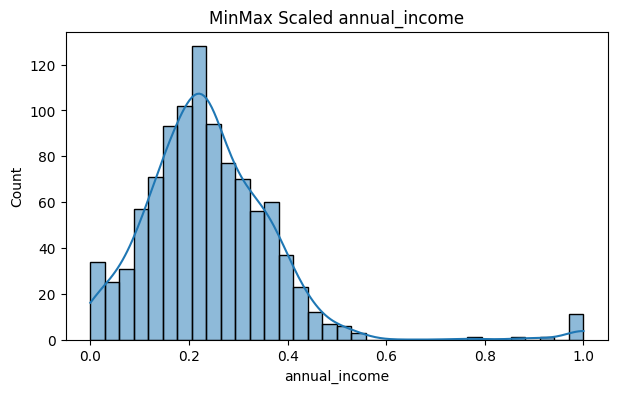

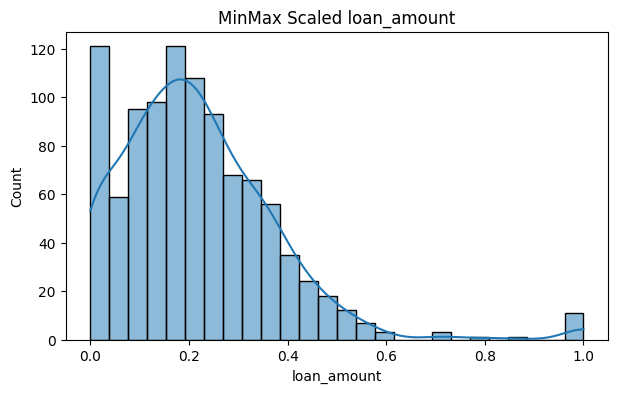

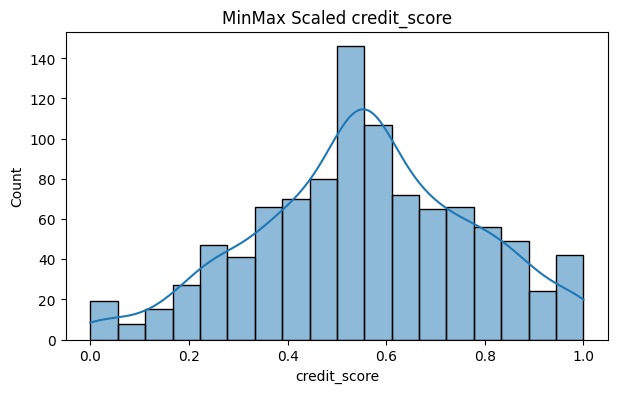

In [179]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'MinMax Scaled {col}')

    plt.show()

The histograms show the distribution of each feature after Min-Max Scaling. The shape of the distribution remains the same, but the values are normalized to a common range.

In [180]:
from sklearn.preprocessing import MaxAbsScaler

maxabs = MaxAbsScaler()

numerical_cols = [
    'annual_income',
    'loan_amount',
    'credit_score'
]

df[numerical_cols] = maxabs.fit_transform(
    df[numerical_cols]
)

df.head()

,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,loan_purpose_Home,loan_purpose_Personal,income_group,transaction_bin,kmeans_bin,annual_income_log,annual_income_sqrt,annual_income_reciprocal,annual_income_boxcox,loan_amount_yeojohnson
0,CUST00001,59.000000,Male,0.0,Salaried,0.229592,0.246236,0.576142,7,196,...,1,0,Low Income,Q2,2,13.304701,774.602117,0.000002,498.475405,0.379060
1,CUST00002,49.000000,Male,0.0,Salaried,0.297768,0.466487,0.555151,7,15,...,0,0,Low Income,Q1,0,13.525803,865.148357,0.000001,544.559894,1.440231
2,CUST00003,35.000000,Female,0.0,Self-Employed,0.102808,0.031999,0.817259,10,362,...,0,0,Low Income,Q3,1,12.688184,569.119654,0.000003,389.466172,-1.413371
3,CUST00004,63.000000,Male,0.0,Salaried,0.229592,0.276025,0.725888,0,359,...,0,0,Low Income,Q3,1,13.304701,774.602117,0.000002,498.475405,0.547169
4,CUST00005,42.327368,Male,0.0,Salaried,0.171930,0.291868,0.631980,1,119,...,0,0,Low Income,Q1,0,13.069874,688.789670,0.000002,453.773853,0.632573


MaxAbsScaler scaled numerical variables relative to their maximum absolute values without changing data sparsity.

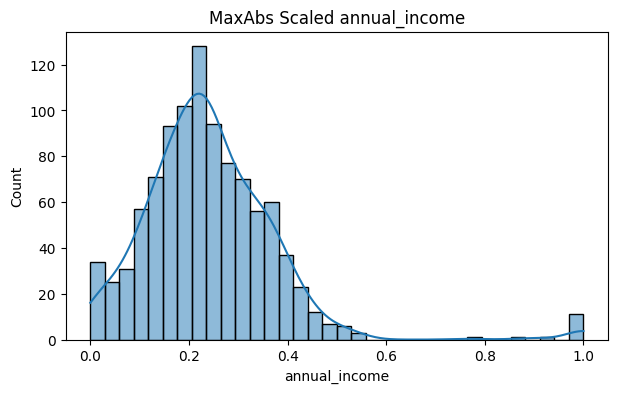

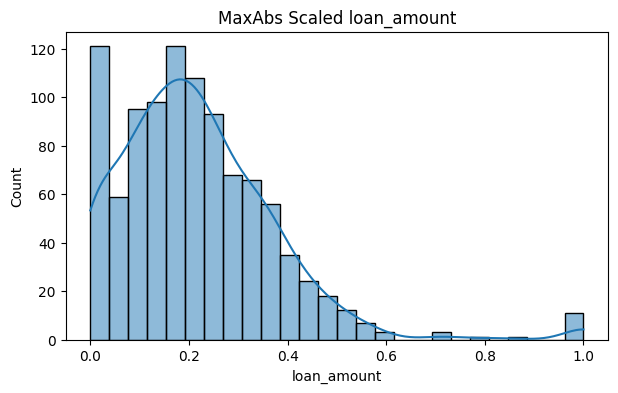

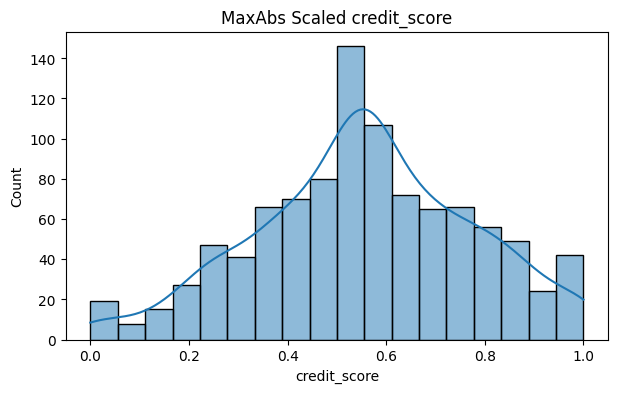

In [181]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'MaxAbs Scaled {col}')

    plt.show()

The histograms show that MaxAbsScaler changes the scale of the data but preserves the overall distribution pattern of each feature.

In [182]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()

numerical_cols = [
    'annual_income',
    'loan_amount',
    'credit_score'
]

df[numerical_cols] = robust.fit_transform(
    df[numerical_cols]
)

df.head()

,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,loan_purpose_Home,loan_purpose_Personal,income_group,transaction_bin,kmeans_bin,annual_income_log,annual_income_sqrt,annual_income_reciprocal,annual_income_boxcox,loan_amount_yeojohnson
0,CUST00001,59.000000,Male,0.0,Salaried,0.000000,0.268296,0.072548,7,196,...,1,0,Low Income,Q2,2,13.304701,774.602117,0.000002,498.475405,0.379060
1,CUST00002,49.000000,Male,0.0,Salaried,0.457344,1.410027,0.000000,7,15,...,0,0,Low Income,Q1,0,13.525803,865.148357,0.000001,544.559894,1.440231
2,CUST00003,35.000000,Female,0.0,Self-Employed,-0.850508,-0.842256,0.905882,10,362,...,0,0,Low Income,Q3,1,12.688184,569.119654,0.000003,389.466172,-1.413371
3,CUST00004,63.000000,Male,0.0,Salaried,0.000000,0.422718,0.590092,0,359,...,0,0,Low Income,Q3,1,13.304701,774.602117,0.000002,498.475405,0.547169
4,CUST00005,42.327368,Male,0.0,Salaried,-0.386817,0.504844,0.265531,1,119,...,0,0,Low Income,Q1,0,13.069874,688.789670,0.000002,453.773853,0.632573



RobustScaler scaled the data using the median and interquartile range, making it less sensitive to outliers.

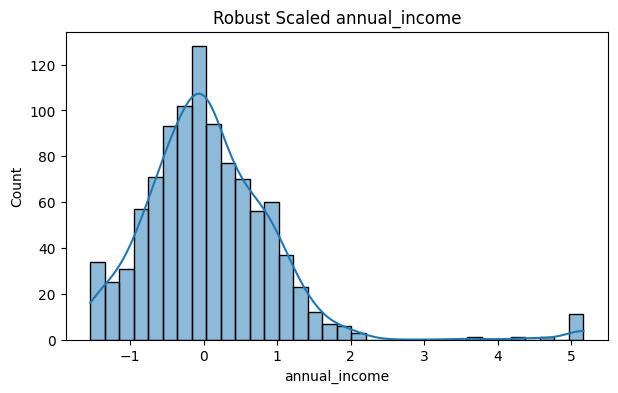

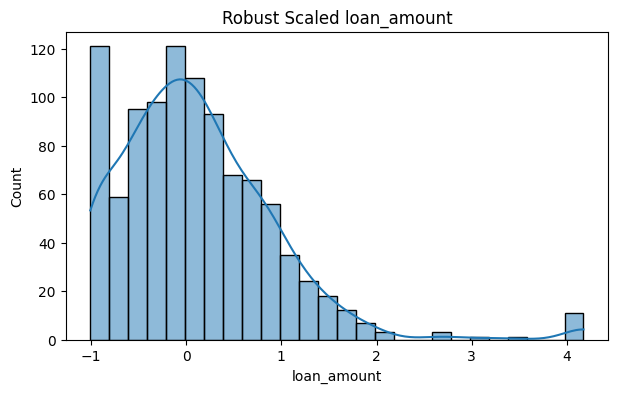

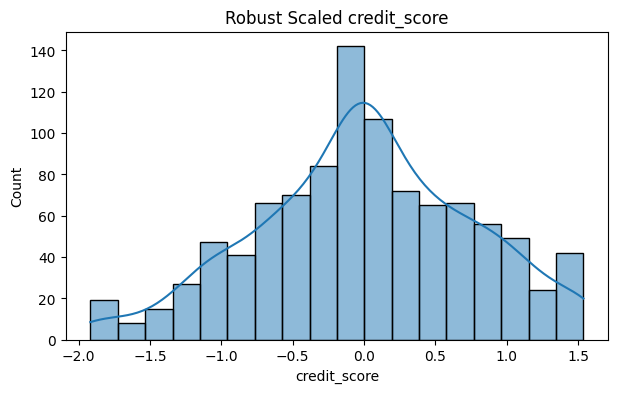

In [183]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Robust Scaled {col}')

    plt.show()

The histograms show the distribution of the scaled variables. RobustScaler preserves the shape of the data while reducing the influence of extreme observations.

**Normalizer transformed each observation to have a unit norm, ensuring consistent magnitude across records.**

In [184]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

numerical_cols = [
    'annual_income',
    'loan_amount',
    'credit_score'
]

df[numerical_cols] = normalizer.fit_transform(
    df[numerical_cols]
)

df.head()

,customer_id,age,gender,education_level,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,...,loan_purpose_Home,loan_purpose_Personal,income_group,transaction_bin,kmeans_bin,annual_income_log,annual_income_sqrt,annual_income_reciprocal,annual_income_boxcox,loan_amount_yeojohnson
0,CUST00001,59.000000,Male,0.0,Salaried,0.000000,0.965331,0.261030,7,196,...,1,0,Low Income,Q2,2,13.304701,774.602117,0.000002,498.475405,0.379060
1,CUST00002,49.000000,Male,0.0,Salaried,0.308528,0.951215,0.000000,7,15,...,0,0,Low Income,Q1,0,13.525803,865.148357,0.000001,544.559894,1.440231
2,CUST00003,35.000000,Female,0.0,Self-Employed,-0.566580,-0.561083,0.603468,10,362,...,0,0,Low Income,Q3,1,12.688184,569.119654,0.000003,389.466172,-1.413371
3,CUST00004,63.000000,Male,0.0,Salaried,0.000000,0.582354,0.812936,0,359,...,0,0,Low Income,Q3,1,13.304701,774.602117,0.000002,498.475405,0.547169
4,CUST00005,42.327368,Male,0.0,Salaried,-0.561252,0.732503,0.385272,1,119,...,0,0,Low Income,Q1,0,13.069874,688.789670,0.000002,453.773853,0.632573


Normalizer was used to scale each data record to a unit norm. It ensures that all observations have the same magnitude while preserving the relative proportions among features. This is particularly useful for similarity and distance-based algorithms.

In [185]:
df.to_csv(
    'customer_credit_risk_final_dataset.csv',
    index=False
)

print("Final Dataset Exported Successfully!")


Final Dataset Exported Successfully!


The Customer Credit Risk dataset was successfully preprocessed through a series of data cleaning and transformation techniques. Missing values were handled appropriately, outliers were treated, new features were engineered, categorical variables were encoded, numerical features were transformed and scaled, and the final dataset was exported. These preprocessing steps improved data quality, ensured consistency, and prepared the dataset for accurate machine learning model development and credit risk analysis.